# NaN-aware Gaussian smoothing

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xrtoolz/blob/main/docs/notebooks/nan_aware_smoothing.ipynb)

This notebook demonstrates coastal smoothing with `gaussian_smooth_masked`, which smooths finite ocean pixels without letting land-mask NaNs erase nearby coastal values.

**What you'll learn:**

1. How standard Gaussian smoothing propagates NaNs near a mask.
2. How normalized convolution keeps finite coastal pixels alive.
3. How to call `gaussian_smooth_masked` on an xarray `DataArray`.

## Setup

`gaussian_smooth_masked` applies a Gaussian filter to both the NaN-filled data and a finite-pixel mask, then divides the two filtered arrays. The result is a Gaussian-weighted average over valid pixels only, while originally masked land pixels remain NaN.

In [1]:
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "xrtoolz @ git+https://github.com/jejjohnson/xrtoolz@main",
        ],
        check=True,
    )

In [2]:
import importlib.util
import warnings

warnings.filterwarnings("ignore", message=r".*IProgress.*")

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from scipy.ndimage import gaussian_filter
from xrtoolz.interpolate import gaussian_smooth_masked

try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p numpy,xarray,matplotlib,xrtoolz")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.10.0

numpy     : 2.4.4
xarray    : 2026.4.0
matplotlib: 3.10.8
xrtoolz  : 0.0.6

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 6.17.0-1010-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## Synthetic coastline

We create a smooth SST-like field on the ocean side of a diagonal coastline and use `NaN` for land. The existing 1-D Gaussian smoother is applied along latitude and longitude to show the standard NaN-propagating behavior.

In [3]:
lat = np.linspace(-4, 4, 80)
lon = np.linspace(-4, 4, 100)
lon2d, lat2d = np.meshgrid(lon, lat)

sst = 18.0 + 1.5 * np.sin(lon2d / 1.5) + 0.75 * np.cos(lat2d / 1.2)
land = lon2d < -0.7 + 0.25 * lat2d
sst = np.where(land, np.nan, sst)

da = xr.DataArray(sst, dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name="sst")

naive = gaussian_filter(da.values, sigma=(2.0, 0.0))
naive = gaussian_filter(naive, sigma=(0.0, 2.0))
masked = gaussian_smooth_masked(da, dim=("lat", "lon"), sigma={"lat": 2.0, "lon": 2.0})

print(f"finite ocean pixels before smoothing: {np.isfinite(da.values).sum()}")
print(f"finite pixels after naive smoothing: {np.isfinite(naive).sum()}")
print(f"finite pixels after NaN-aware smoothing: {np.isfinite(masked.values).sum()}")

finite ocean pixels before smoothing: 4693
finite pixels after naive smoothing: 3862
finite pixels after NaN-aware smoothing: 4693


## Coastline comparison

The standard smoother loses a band of coastal ocean because NaNs propagate through the Gaussian support. The NaN-aware smoother keeps ocean pixels finite by normalizing by the Gaussian-smoothed valid-data mask.

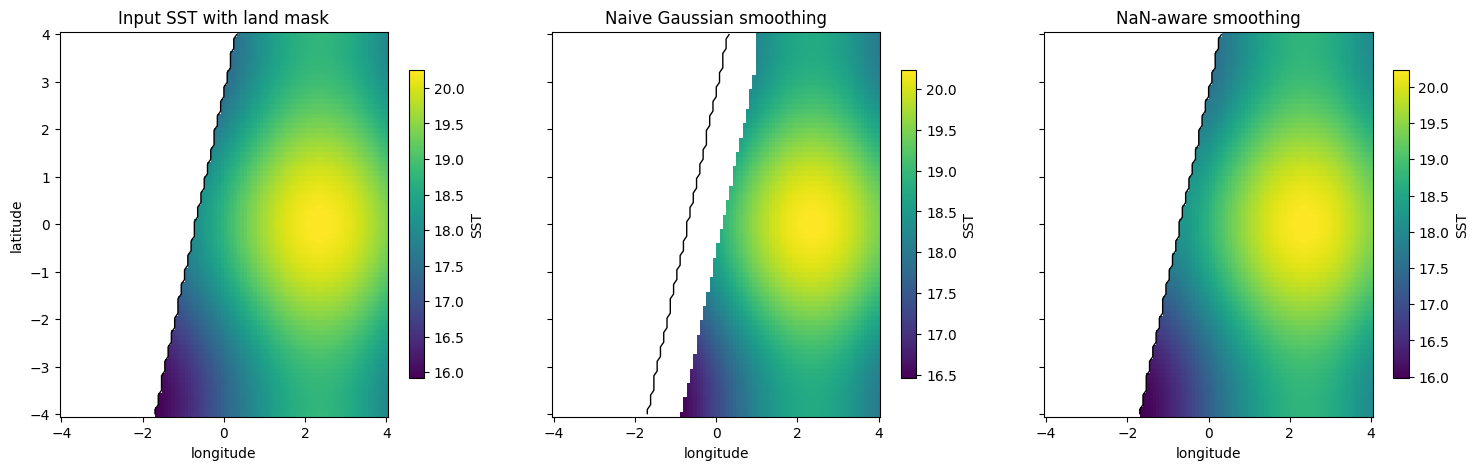

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
fields = [da.values, naive, masked.values]
titles = ["Input SST with land mask", "Naive Gaussian smoothing", "NaN-aware smoothing"]

for ax, field, title in zip(axes, fields, titles, strict=True):
    image = ax.pcolormesh(lon, lat, field, shading="auto")
    ax.contour(lon, lat, land, levels=[0.5], colors="k", linewidths=1.0)
    ax.set_title(title)
    ax.set_xlabel("longitude")
    fig.colorbar(image, ax=ax, shrink=0.8, label="SST")

axes[0].set_ylabel("latitude")
plt.show()

## Takeaways

Use `gaussian_smooth_masked` when NaNs encode a physical mask such as land, sea ice, or missing swaths. The result is interpolation-style smoothing rather than flux-preserving smoothing: values near masks are averaged over the available support, and originally masked pixels stay masked.